## Imports
Libraries for data manipulation, preprocessing, clustering and statistics.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, unicodedata
import json
import sklearn

from scipy import stats
from scipy.spatial.distance import cdist
from scipy.sparse import issparse
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 800
pd.set_option("display.max_columns", 50)
maroon_cmap = LinearSegmentedColormap.from_list('maroon_theme', ['white', '#591427'])

## Data loading and cleaning
Loads the mobility dataset, harmonizes country names, and normalizes the *Fewer Opportunities* column into Yes/No/Unknown.

In [4]:
mob = pd.read_csv("./Datasets/Processed/hicp_mobility_ranking_dataset.csv")

def clean_fewer_opportunities(v):
    v = str(v).strip().lower()
    return {"yes": "Yes", "1": "Yes", "no": "No", "0": "No"}.get(v, "Unknown")

mob["Fewer_Opportunities_clean"] = mob["Fewer Opportunities"].apply(clean_fewer_opportunities)
mob.drop(columns=["Fewer Opportunities"], inplace=True)
mob.rename(columns={"Fewer_Opportunities_clean": "Fewer Opportunities"}, inplace=True)
mob.head()

C:\Users\rpasq\AppData\Local\Temp\ipykernel_8340\981874542.py:1: DtypeWarning: Columns (0: Fewer Opportunities) have mixed types. Specify dtype option on import or set low_memory=False.
  mob = pd.read_csv("./Datasets/Processed/hicp_mobility_ranking_dataset.csv")


,Mobility Duration,Field of Education,Academic Year,Participant Country,Education Level,Participant Gender,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization,Sending Institution Rank,Receiving Institution Rank,Fewer Opportunities
0,61,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,22,Austria,130.4,WIEN,WU,Germany,125.9,Munich,-,NaN,NaN,No
1,101,Economics,2023,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,27,Austria,130.4,WIEN,WU,France,120.5,Toulouse,Université Toulouse Capitole,NaN,NaN,No
2,121,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,22,Austria,130.4,WIEN,WU,France,120.5,Paris,-,NaN,NaN,No
3,171,Business and administration,2023,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,22,Austria,130.4,WIEN,WU,France,120.5,Paris,-,NaN,NaN,No
4,86,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,23,Austria,130.4,WIEN,WU,Germany,125.9,Hamburg,-,NaN,NaN,No


## Feature engineering — field of study
Maps raw *Field of Education* values onto the 10 ISCED-F macro-fields, to avoid an overly sparse one-hot encoding.


In [5]:
with open('mapping_results.json', 'r') as map:
    mapping_data = json.load(map)

## Feature engineering — HICP
Winsorizes the HICP index (to limit the effect of Türkiye-related outliers), computes the sending/receiving differential.

In [6]:
mob2 = mob.copy()
mob2["HICP diff"] = mob2["Receiving Country HICP"] - mob2["Sending Country HICP"]

mob2.head()

,Mobility Duration,Field of Education,Academic Year,Participant Country,Education Level,Participant Gender,Participant Age,Sending Country,Sending Country HICP,Sending City,Sending Organization,Receiving Country,Receiving Country HICP,Receiving City,Receiving Organization,Sending Institution Rank,Receiving Institution Rank,Fewer Opportunities,HICP diff
0,61,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,22,Austria,130.4,WIEN,WU,Germany,125.9,Munich,-,NaN,NaN,No,-4.5
1,101,Economics,2023,Germany,ISCED-7 - Second cycle / Master’s or equivalen...,Male,27,Austria,130.4,WIEN,WU,France,120.5,Toulouse,Université Toulouse Capitole,NaN,NaN,No,-9.9
2,121,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Female,22,Austria,130.4,WIEN,WU,France,120.5,Paris,-,NaN,NaN,No,-9.9
3,171,Business and administration,2023,Germany,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,22,Austria,130.4,WIEN,WU,France,120.5,Paris,-,NaN,NaN,No,-9.9
4,86,Business and administration,2023,Austria,ISCED-6 - First cycle / Bachelor’s or equivale...,Male,23,Austria,130.4,WIEN,WU,Germany,125.9,Hamburg,-,NaN,NaN,No,-4.5


## Split into categorical and numerial columns

In [7]:
student_num_cols = ["Mobility Duration", "Participant Age", "Sending Country HICP", "Receiving Country HICP", "Sending Institution Rank", "Receiving Institution Rank"]
student_cat_cols = ["Participant Gender", "Fewer Opportunities", "Education Level", "Field of Education"]


# features used for external validation >:3
eta_cols = student_num_cols + ["HICP diff"]
mob2[eta_cols] = mob2[eta_cols].fillna(mob2[eta_cols].median())
print(mob2[eta_cols].isna().sum())

Mobility Duration             0
Participant Age               0
Sending Country HICP          0
Receiving Country HICP        0
Sending Institution Rank      0
Receiving Institution Rank    0
HICP diff                     0
dtype: int64


## Preprocessing pipeline
Defines a function that builds the feature matrix by scaling/one-hot-encoding each block. We use a single **baseline** weighting (equal weight to numerical and categorical blocks).

In [8]:
mob3 = mob2.sample(frac=0.01, random_state=42).reset_index(drop=True)
mob3.shape

(31730, 19)

In [9]:
def build_matrix(weights):
    ct = ColumnTransformer([
        ("student_num", StandardScaler(), student_num_cols),
        ("student_cat", OneHotEncoder(handle_unknown="infrequent_if_exist"), student_cat_cols),
    ], transformer_weights=weights)

    Xt = ct.fit_transform(mob3)
    if issparse(Xt):
        Xt = Xt.toarray()

    feature_names = ct.get_feature_names_out()
    return Xt, feature_names

version = {
    "baseline": {"student_num": 1, "student_cat": 1},
}

## Elbow and silhouette per version
For each weighted version, scans k=2..10 with elbow and silhouette, automatically picks the best k (excluding k=2, which only isolates outliers) and trains the final KMeans.

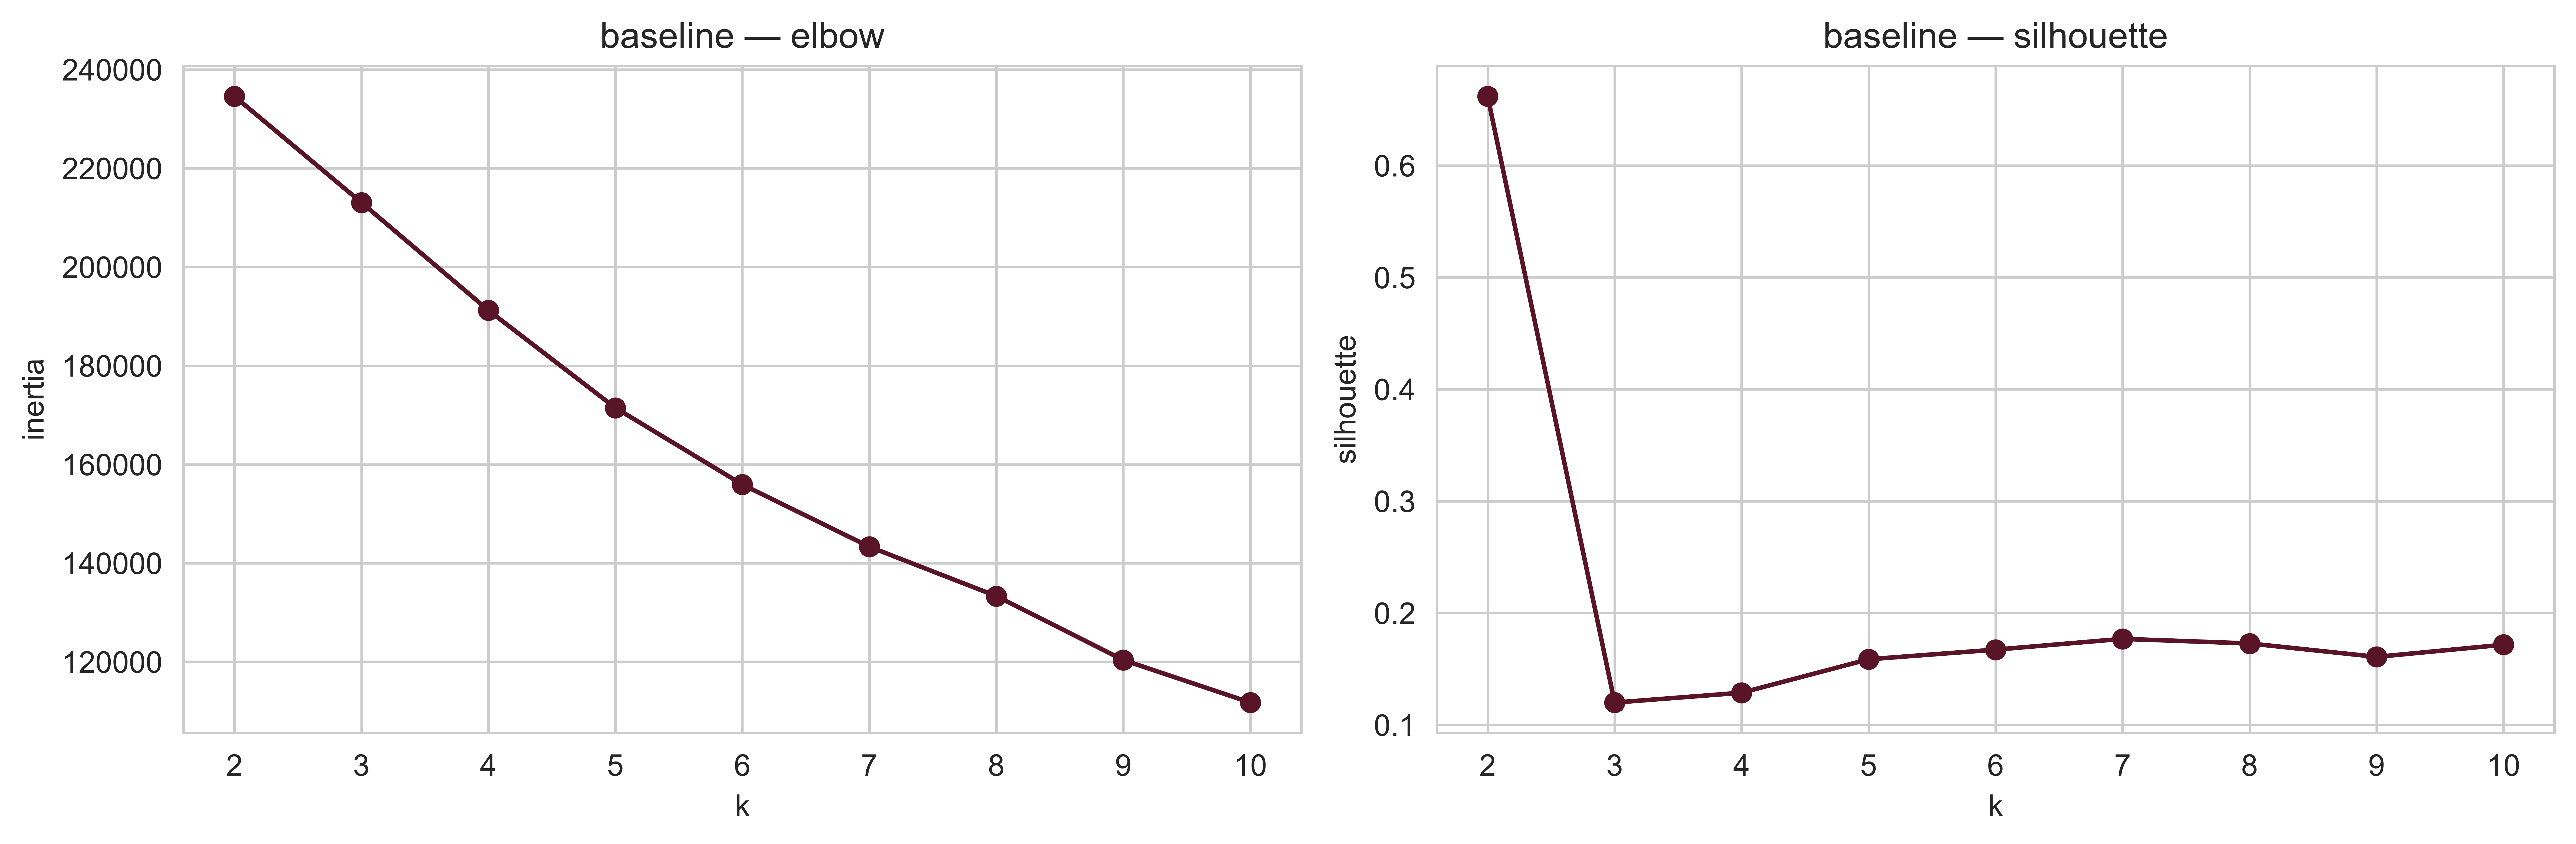

baseline: best_k=7, silhouette=0.177


In [10]:
name = "baseline"
w = version[name]

Xt, feat_names = build_matrix(w)
inertias, sils = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(Xt)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xt, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#591427")
axes[0].set_title(f"{name} — elbow")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")

axes[1].plot(list(k_range), sils, marker="o", color="#591427")
axes[1].set_title(f"{name} — silhouette")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")

plt.tight_layout()
plt.savefig(f"clustering_predict_{name}.png", dpi=800)
plt.show()

best_k = list(k_range)[int(np.argmax(sils[1:])) + 1]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_final = km_final.fit_predict(Xt)
sil_final = silhouette_score(Xt, labels_final)

results = {name : {"X": Xt, "feature_names": feat_names, "k": best_k, "labels": labels_final, "silhouette": sil_final}}
print(f"{name}: best_k={best_k}, silhouette={sil_final:.3f}")

## Cluster separation in feature space

PC1 (15.4% of variance) is dominated by: student_num__Sending Country HICP
PC2 (13.4% of variance) is dominated by: student_num__Participant Age


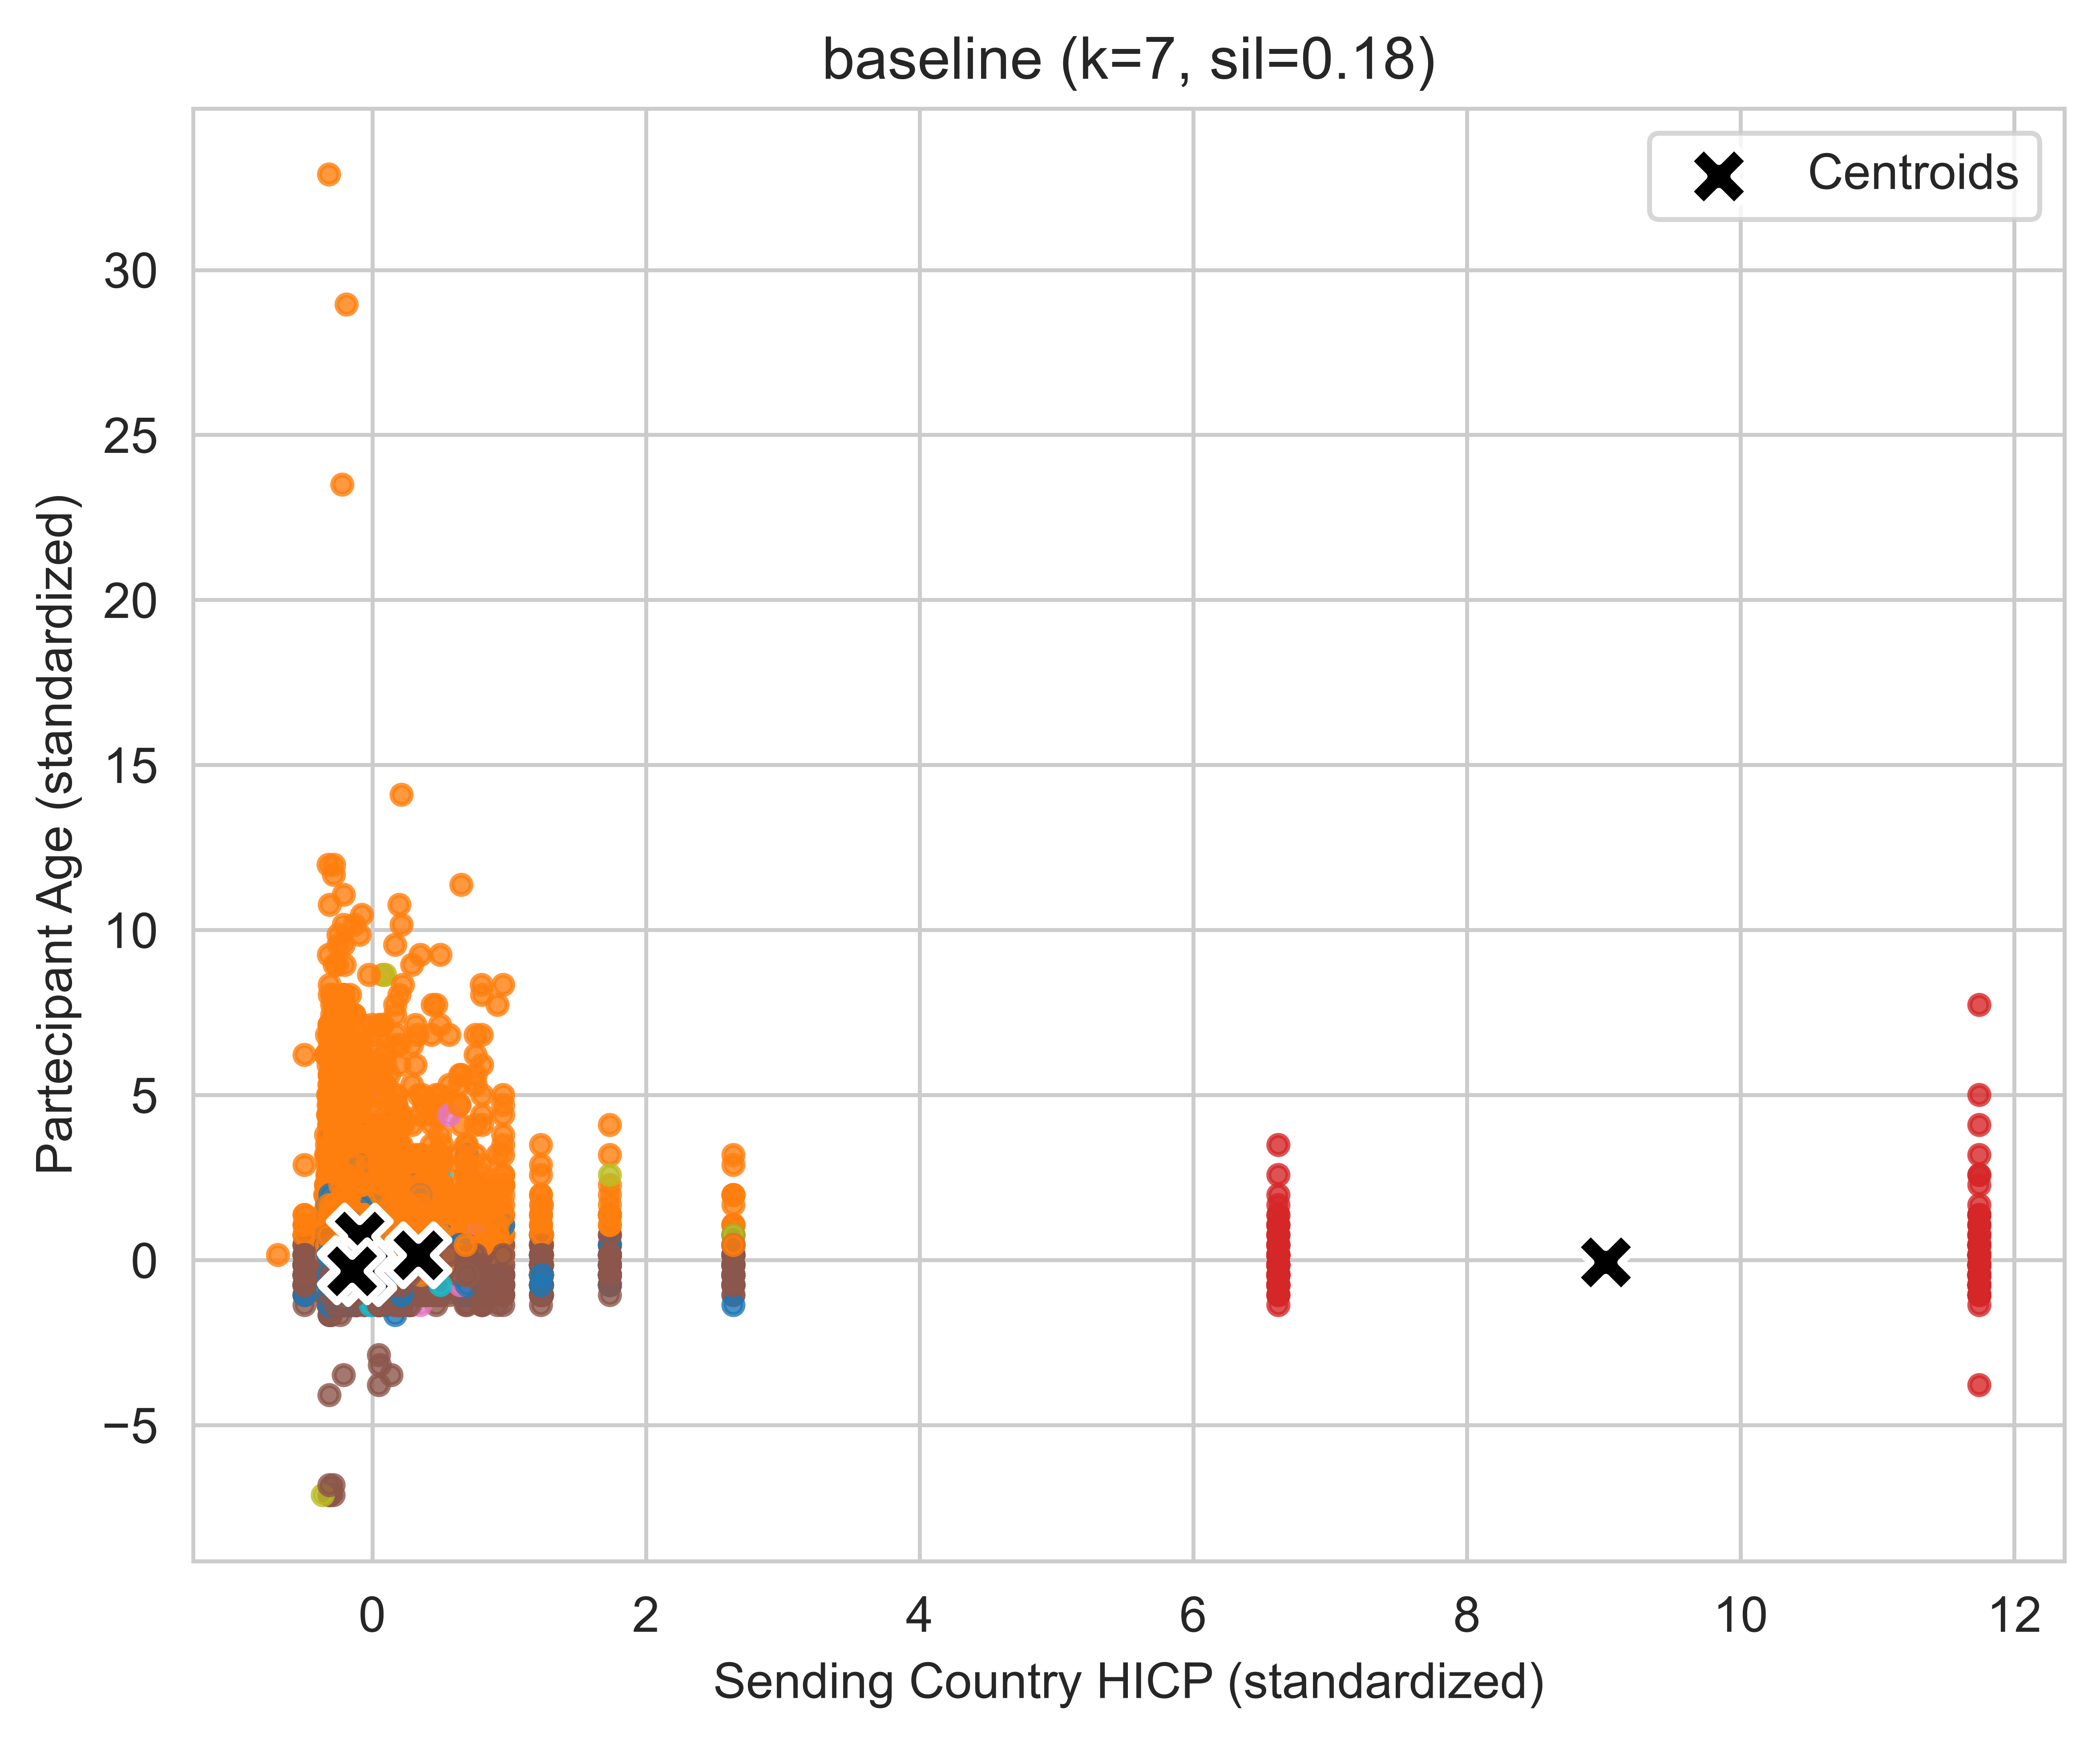

In [44]:
name, r = next(iter(results.items()))
X_df = pd.DataFrame(r["X"], columns=r["feature_names"])
pca = PCA(n_components=2, random_state=42)
pca.fit(X_df)
k_r, sil_r = r["k"], r["silhouette"]

feat_names_in = pca.feature_names_in_
loadings = pca.components_
top_pc1 = feat_names_in[np.argmax(np.abs(loadings[0]))]
top_pc2 = feat_names_in[np.argmax(np.abs(loadings[1]))]
var_ratio = pca.explained_variance_ratio_

print(f"PC1 ({var_ratio[0]:.1%} of variance) is dominated by: {top_pc1}")
print(f"PC2 ({var_ratio[1]:.1%} of variance) is dominated by: {top_pc2}")

x_vals = X_df[top_pc1].values
y_vals = X_df[top_pc2].values

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x_vals, y_vals, c=r["labels"], cmap="tab10", s=15, alpha=0.8)

centroids = np.array([
    [x_vals[r["labels"] == i].mean(), y_vals[r["labels"] == i].mean()]
    for i in range(k_r)
])
ax.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=150,
           edgecolor="white", linewidth=1.5, label="Centroids")
ax.legend()

ax.set_xlabel(f"Sending Country HICP (standardized)")
ax.set_ylabel(f"Partecipant Age (standardized)")
ax.set_title(f"{name} (k={k_r}, sil={sil_r:.2f})")

plt.tight_layout()
plt.savefig("./Plots/clustering_comparison.png", dpi=800)
plt.show()

## Cluster assignment
Only one version (baseline) is used, so its labels are assigned directly to the main dataframe — no comparison across versions is needed.

In [12]:
mob3["cluster"] = results["baseline"]["labels"]

## Per-sample silhouette plot
Shows the distribution of silhouette coefficients per individual sample, grouped by cluster, for the chosen version.

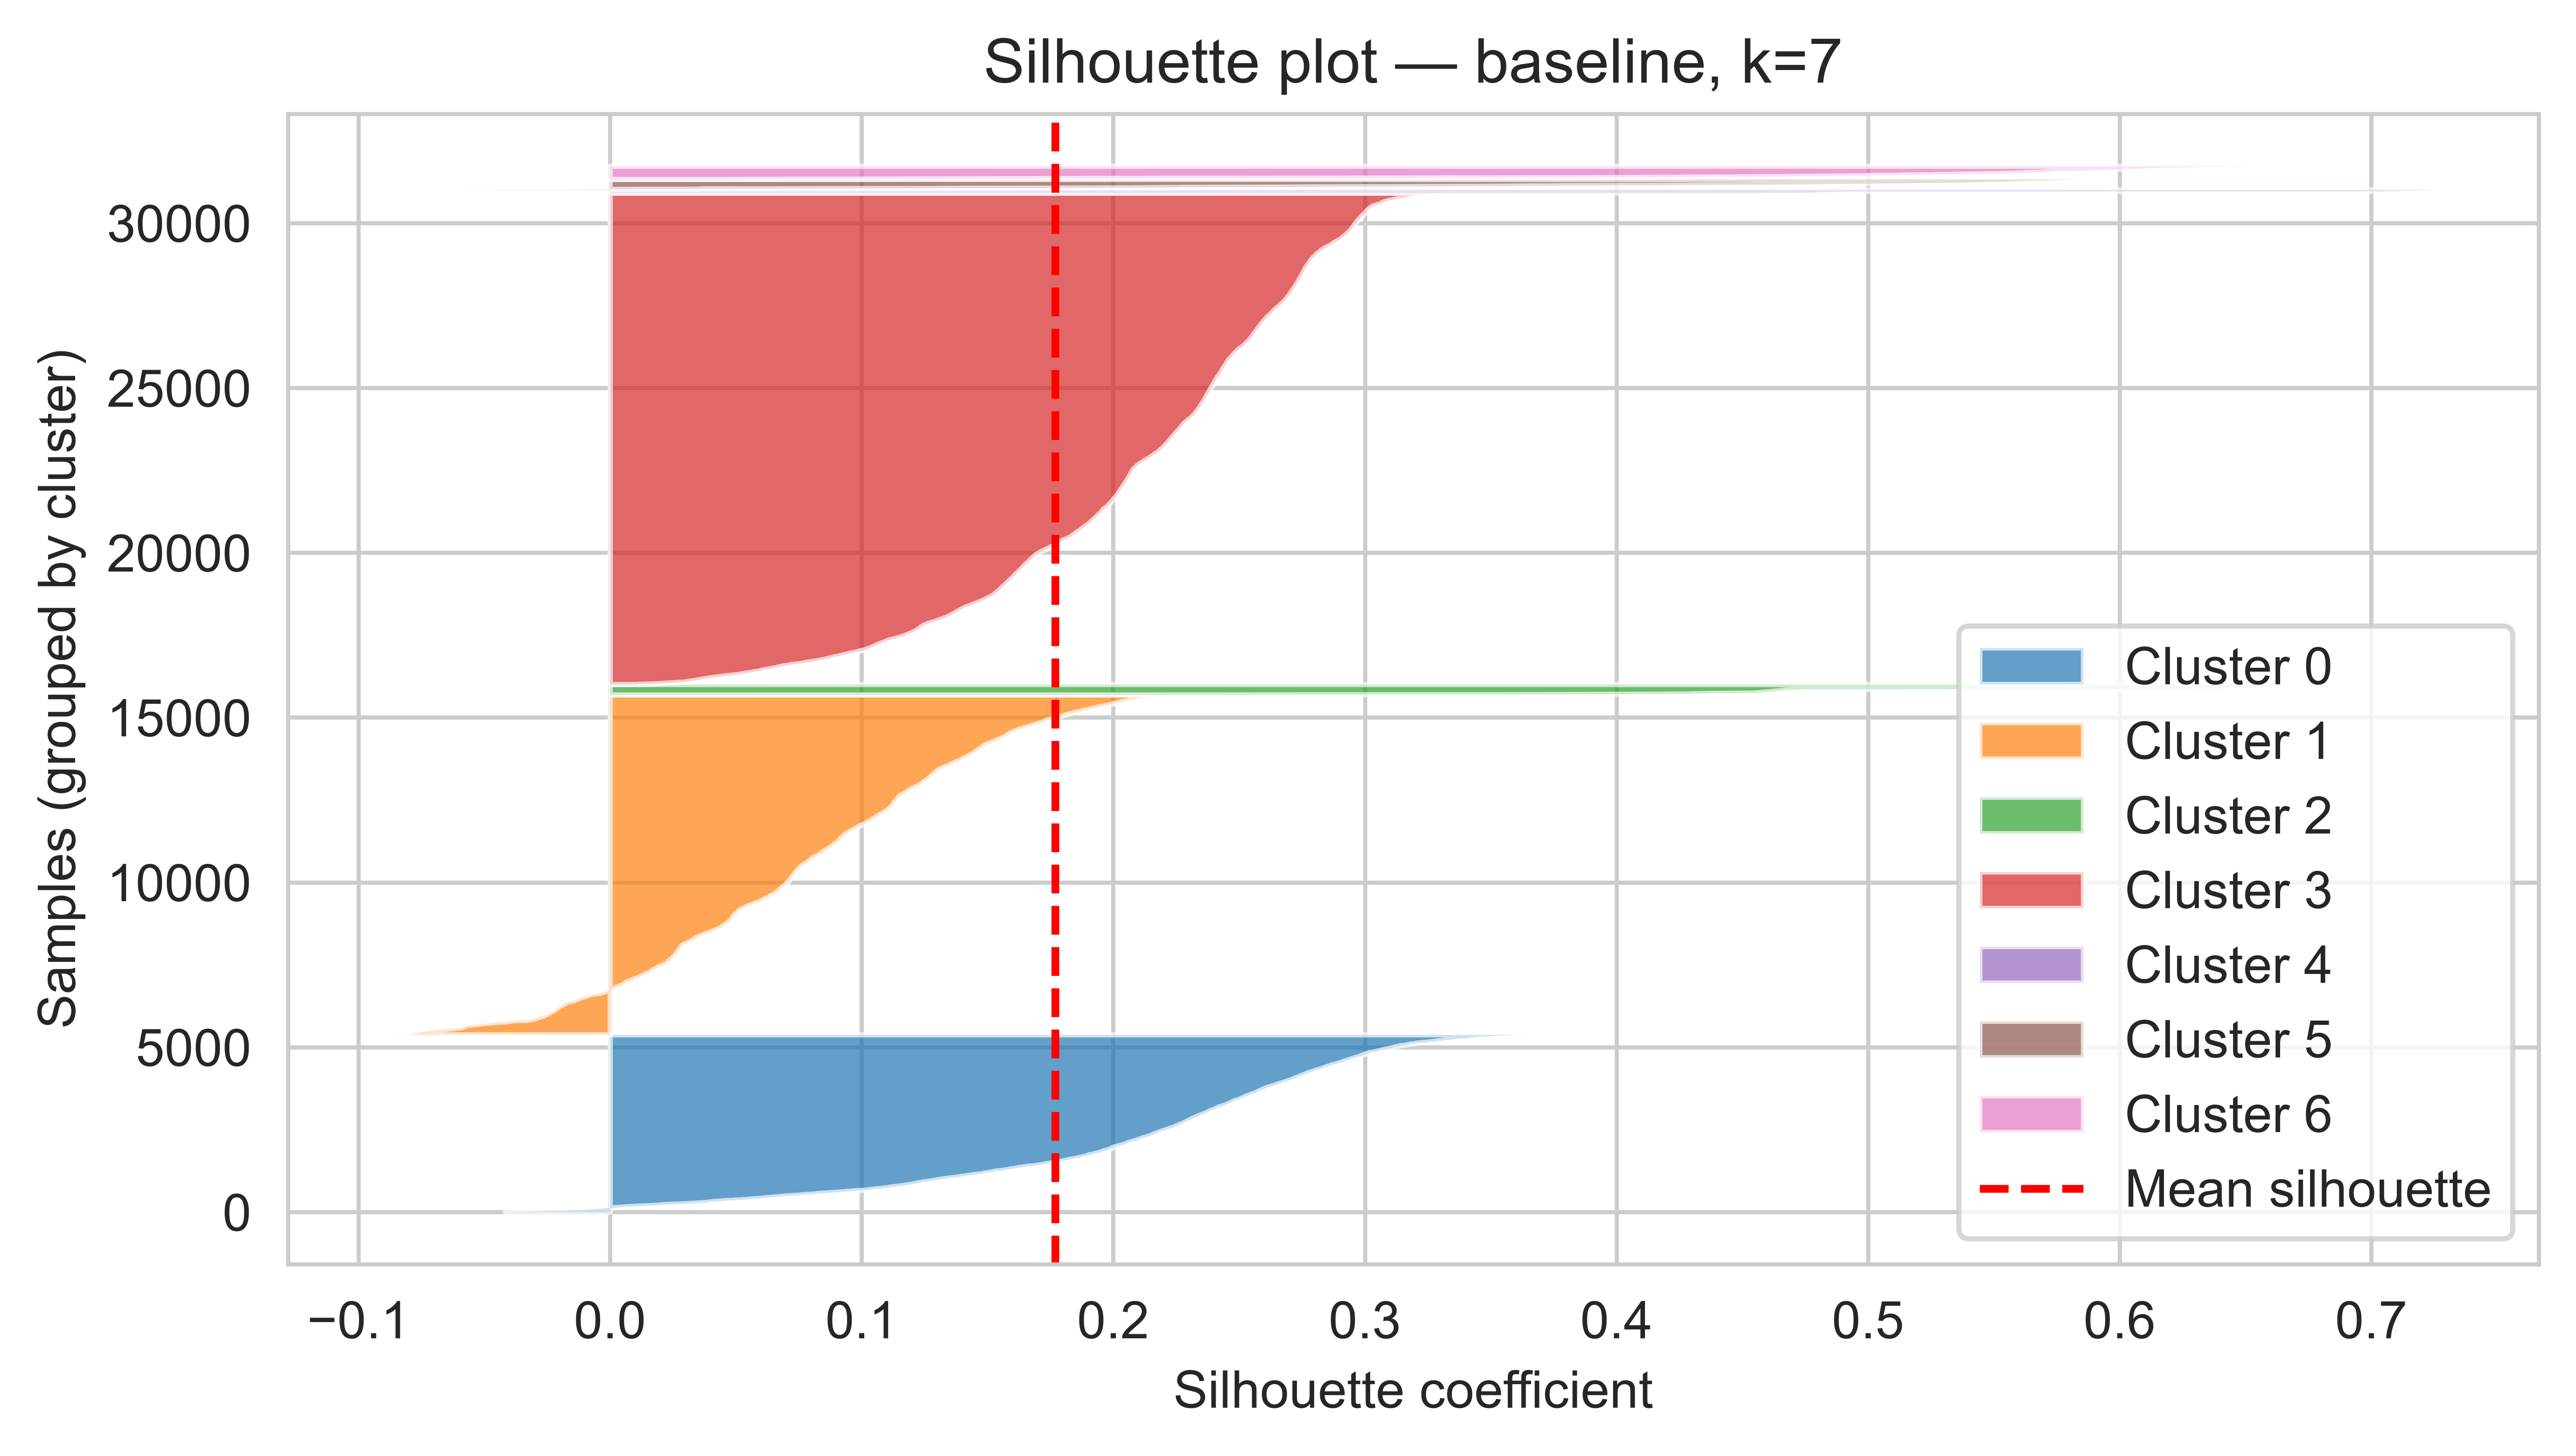

In [14]:
sil_vals = silhouette_samples(results["baseline"]["X"], mob3["cluster"])
best_k_final = results["baseline"]["k"]
fig, ax = plt.subplots(figsize=(7, 4))
y_lower = 0

for i in sorted(mob3["cluster"].unique()):
    vals = np.sort(sil_vals[mob3["cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7, label=f"Cluster {i}")
    y_lower = y_upper

ax.axvline(sil_vals.mean(), color="red", linestyle="--", label="Mean silhouette")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Samples (grouped by cluster)")
ax.set_title(f"Silhouette plot — baseline, k={best_k_final}")
ax.legend()
plt.tight_layout()
plt.savefig(f"./Plots/silhouette_plot_baseline.png", dpi=800)
plt.show()

## Standardized profile heatmap
Z-score of each cluster's mean relative to the overall mean, for numeric features.

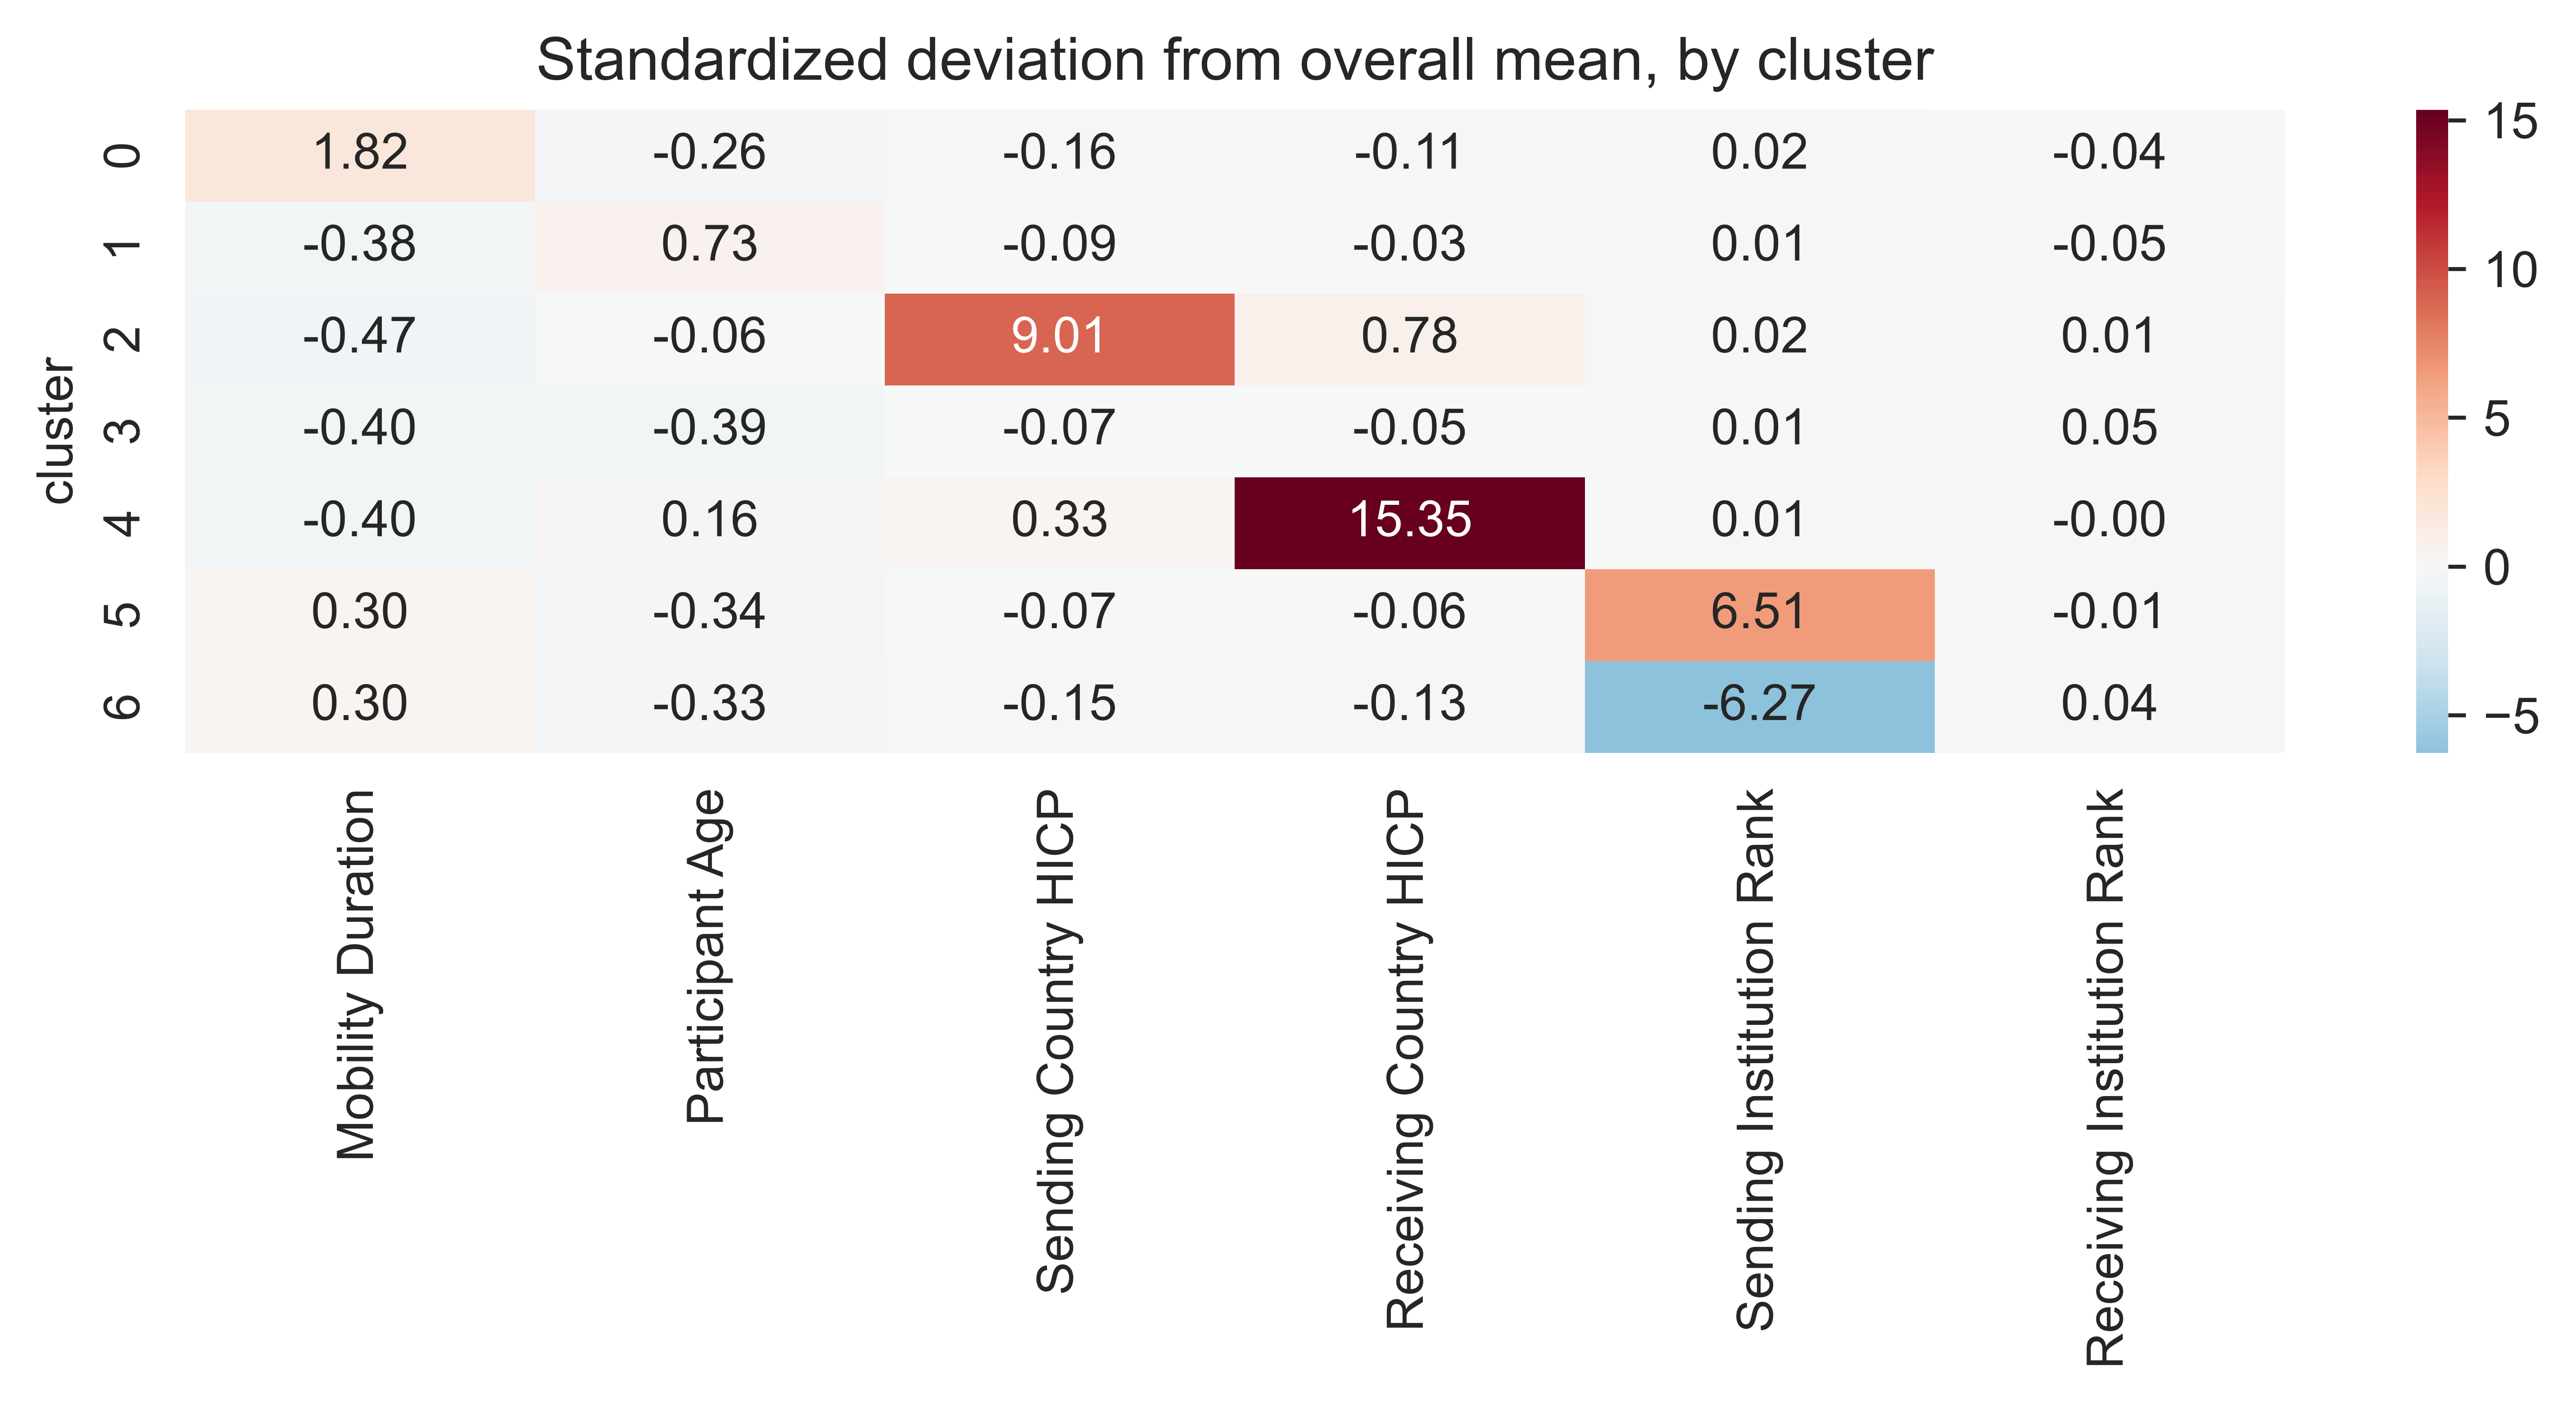

In [16]:
z_profile = (mob3.groupby("cluster")[student_num_cols].mean() - mob3[student_num_cols].mean()) / mob3[student_num_cols].std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(z_profile, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Standardized deviation from overall mean, by cluster")
plt.tight_layout()
plt.savefig(f"./Plots/cluster_profile_heatmap.png", dpi=800)
plt.show()

## Cluster centroids table

In [17]:
centroid_num = mob3.groupby("cluster")[student_num_cols].mean().round(2)
centroid_num.style.background_gradient(cmap=maroon_cmap, axis=0).format("{:.2f}").set_caption("Centroids — numeric features (original units)")

,Mobility Duration,Participant Age,Sending Country HICP,Receiving Country HICP,Sending Institution Rank,Receiving Institution Rank
cluster,,,,,,
0,280.14,21.63,105.93,106.20,174.32,153.08
1,119.71,24.89,108.52,108.03,174.10,152.88
2,113.43,22.31,464.21,127.62,174.20,154.20
3,118.75,21.20,109.56,107.66,174.14,155.25
4,118.55,23.01,125.21,476.88,174.00,154.00
5,169.03,21.38,109.36,107.43,314.34,153.81
6,169.48,21.40,106.32,105.72,38.47,155.01


In [18]:
cat_centroid_rows = {}
for feat in student_cat_cols:
    row = {}
    for cl in sorted(mob3["cluster"].unique()):
        vc = mob3.loc[mob3["cluster"] == cl, feat].value_counts(normalize=True)
        row[cl] = f"{vc.index[0]} ({vc.iloc[0]:.0%})"
    cat_centroid_rows[feat] = row

df_cat_centroids = pd.DataFrame(cat_centroid_rows).T
df_cat_centroids.columns.name = "cluster"
df_cat_centroids.style.set_caption("Centroids — categorical features (most frequent category, share)")

cluster,0,1,2,3,4,5,6
Participant Gender,Female (60%),Female (56%),Female (56%),Female (65%),Female (56%),Female (56%),Female (68%)
Fewer Opportunities,No (79%),No (85%),No (96%),No (85%),No (76%),No (86%),No (87%)
Education Level,ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (73%),ISCED-7 - Second cycle / Master’s or equivalent level (EQF-7) (82%),ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (90%),ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (93%),ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (73%),ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (85%),ISCED-6 - First cycle / Bachelor’s or equivalent level (EQF-6) (72%)
Field of Education,Business and administration (10%),Business and administration (12%),Engineering and engineering trades (10%),Business and administration (16%),Business and administration (14%),Business and administration (16%),Languages (29%)


## Cluster Size
Count of observations per cluster, useful for correctly interpreting η² and Cramér’s V results

In [19]:
mob3["cluster"].value_counts().sort_index()

cluster
0     5381
1    10312
2      315
3    14907
4      100
5      315
6      400
Name: count, dtype: int64

## Statistical tests across clusters
Eta squared method for numeric features.

In [21]:
def eta_squared(*groups):
    all_data = np.concatenate(groups)
    grand_mean = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((all_data - grand_mean)**2)
    return ss_between / ss_total

eta_rows = []

for col in eta_cols:
    groups = [
        mob3.loc[mob3["cluster"] == c, col].dropna().values
        for c in sorted(mob3["cluster"].unique())
    ]

    eta2 = eta_squared(*groups)
    _, p_val = stats.f_oneway(*groups)

    eta_rows.append({
        "Feature": col,
        "η²": round(eta2, 4),
        "p-value": p_val
    })

df_eta = (
    pd.DataFrame(eta_rows)
    .sort_values("η²", ascending=False)
    .reset_index(drop=True)
)

df_eta.style.background_gradient(cmap=maroon_cmap, subset=["η²"]).format({"η²": "{:.4f}", "p-value": "{:.2e}"})

,Feature,η²,p-value
0,Sending Institution Rank,0.9162,0.00e+00
1,HICP diff,0.8359,0.00e+00
2,Sending Country HICP,0.8161,0.00e+00
3,Receiving Country HICP,0.7522,0.00e+00
4,Mobility Duration,0.6889,0.00e+00
5,Participant Age,0.2572,0.00e+00
6,Receiving Institution Rank,0.0025,2.52e-15


Cramer's V method for categorical features.

In [25]:
def cramers_v(confusion_matrix):
    chi2, p, _, _ = stats.chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return v, p

cramers_rows = []

for col in student_cat_cols + ["Academic Year"]:
    ct = pd.crosstab(mob3["cluster"], mob3[col])

    if ct.shape[0] > 1 and ct.shape[1] > 1:
        v, p = cramers_v(ct)
    else:
        v = np.nan
        p = np.nan

    cramers_rows.append({
        "Feature": col,
        "Cramér's V": round(v, 4) if not np.isnan(v) else np.nan,
        "p-value": p if not np.isnan(p) else np.nan
    })

df_cramers = (
    pd.DataFrame(cramers_rows)
    .sort_values("Cramér's V", ascending=False)
    .reset_index(drop=True)
)

df_cramers.style.background_gradient(cmap=maroon_cmap, subset=["Cramér's V"]).format({"Cramér's V": "{:.4f}", "p-value": "{:.2e}"})


,Feature,Cramér's V,p-value
0,Education Level,0.3584,0.00e+00
1,Field of Education,0.1542,0.00e+00
2,Academic Year,0.0951,0.00e+00
3,Fewer Opportunities,0.0599,6.79e-42
4,Participant Gender,0.0574,4.56e-38


## Multiple testing correction
When testing many features simultaneously (via η² and Cramér’s V), the risk of false positives increases. We therefore apply FDR correction (Benjamini–Hochberg) to the p‑values in both tables.

In [ ]:
df_eta["significant_FDR"] = multipletests(df_eta["p-value"], alpha=0.05, method="fdr_bh")[0]
df_cramers_valid = df_cramers.dropna(subset=["p-value"]).copy()
df_cramers_valid["significant_FDR"] = multipletests(df_cramers_valid["p-value"], alpha=0.05, method="fdr_bh")[0]
df_cramers = df_cramers.merge(df_cramers_valid[["Feature", "significant_FDR"]], on="Feature", how="left")

print("Significant η² after FDR:")
display(df_eta[["Feature", "η²", "p-value", "significant_FDR"]])

print("\nSignificant Cramér's V after FDR:")
display(df_cramers[["Feature", "Cramér's V", "p-value", "significant_FDR"]])

Significant η² after FDR:


,Feature,η²,p-value,significant_FDR
0,Sending Institution Rank,0.9162,0.000000e+00,True
1,HICP diff,0.8359,0.000000e+00,True
2,Sending Country HICP,0.8161,0.000000e+00,True
3,Receiving Country HICP,0.7522,0.000000e+00,True
4,Mobility Duration,0.6889,0.000000e+00,True
5,Participant Age,0.2572,0.000000e+00,True
6,Receiving Institution Rank,0.0025,2.520547e-15,True



Significant Cramér's V after FDR:


,Feature,Cramér's V,p-value,significant_FDR
0,Education Level,0.3584,0.000000e+00,True
1,Field of Education,0.1542,0.000000e+00,True
2,Academic Year,0.0951,0.000000e+00,True
3,Fewer Opportunities,0.0599,6.786336e-42,True
4,Participant Gender,0.0574,4.556637e-38,True


## Effect size interpretation
Adds qualitative labels to η² and Cramér’s V (per Cohen) to make effect sizes immediately interpretable, especially when statistical significance in mob3 may be misleading.

In [38]:
def interpret_eta2(v):
    if pd.isna(v): return "n/a"
    if v < 0.01: return "negligible"
    if v < 0.06: return "small"
    if v < 0.14: return "medium"
    return "large"

def interpret_cramers_v(v):
    if pd.isna(v): return "n/a"
    if v < 0.10: return "negligible"
    if v < 0.30: return "small"
    if v < 0.50: return "medium"
    return "large"

df_eta["effect_size"] = df_eta["η²"].apply(interpret_eta2)
df_cramers["effect_size"] = df_cramers["Cramér's V"].apply(interpret_cramers_v)

display(df_eta[["Feature", "η²", "effect_size", "significant_FDR"]])
display(df_cramers[["Feature", "Cramér's V", "effect_size", "significant_FDR"]])

,Feature,η²,effect_size,significant_FDR
0,Sending Institution Rank,0.9162,large,True
1,HICP diff,0.8359,large,True
2,Sending Country HICP,0.8161,large,True
3,Receiving Country HICP,0.7522,large,True
4,Mobility Duration,0.6889,large,True
5,Participant Age,0.2572,large,True
6,Receiving Institution Rank,0.0025,negligible,True


,Feature,Cramér's V,effect_size,significant_FDR
0,Education Level,0.3584,medium,True
1,Field of Education,0.1542,small,True
2,Academic Year,0.0951,negligible,True
3,Fewer Opportunities,0.0599,negligible,True
4,Participant Gender,0.0574,negligible,True


## Combined feature ranking
“Combines η² and Cramér’s V into a unified ranking (both normalized to [0, 1]) to identify which variables most strongly define the clusters, regardless of whether they are numerical or categorical.

In [39]:
combined = pd.concat([
    df_eta.rename(columns={"η²": "effect_value"})[["Feature", "effect_value", "effect_size", "significant_FDR"]].assign(type="numeric (η²)"),
    df_cramers.rename(columns={"Cramér's V": "effect_value"})[["Feature", "effect_value", "effect_size", "significant_FDR"]].assign(type="categorical (Cramér's V)"),
], ignore_index=True).sort_values("effect_value", ascending=False).reset_index(drop=True)

combined.style.background_gradient(cmap=maroon_cmap, subset=["effect_value"]).format({"effect_value": "{:.4f}"})

,Feature,effect_value,effect_size,significant_FDR,type
0,Sending Institution Rank,0.9162,large,True,numeric (η²)
1,HICP diff,0.8359,large,True,numeric (η²)
2,Sending Country HICP,0.8161,large,True,numeric (η²)
3,Receiving Country HICP,0.7522,large,True,numeric (η²)
4,Mobility Duration,0.6889,large,True,numeric (η²)
5,Education Level,0.3584,medium,True,categorical (Cramér's V)
6,Participant Age,0.2572,large,True,numeric (η²)
7,Field of Education,0.1542,small,True,categorical (Cramér's V)
8,Academic Year,0.0951,negligible,True,categorical (Cramér's V)
9,Fewer Opportunities,0.0599,negligible,True,categorical (Cramér's V)


## Post-hoc (numerical)
η² indicates how strongly a feature separates the clusters overall, but not which specific cluster pairs differ. Tukey’s HSD on the numerical feature with the highest η² provides the required pairwise comparisons.

In [40]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

top_numeric_feature = df_eta.iloc[0]["Feature"]
print(f"Numeric feature with the strongest effect: {top_numeric_feature}")

tukey = pairwise_tukeyhsd(
    endog=mob3[top_numeric_feature].dropna(),
    groups=mob3.loc[mob3[top_numeric_feature].notna(), "cluster"],
    alpha=0.05
)
print(tukey)

Numeric feature with the strongest effect: Sending Institution Rank
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
     0      1   -0.2231  0.339    -0.533    0.0868  False
     0      2   -0.1215 0.9999   -1.1897    0.9467  False
     0      3   -0.1828 0.5211   -0.4759    0.1102  False
     0      4   -0.3183 0.9988   -2.1781    1.5414  False
     0      5  140.0182    0.0    138.95  141.0864   True
     0      6 -135.8533    0.0 -136.8083 -134.8984   True
     1      2    0.1016    1.0   -0.9524    1.1556  False
     1      3    0.0403 0.9988   -0.1957    0.2763  False
     1      4   -0.0952    1.0   -1.9468    1.7564  False
     1      5  140.2413    0.0  139.1873  141.2953   True
     1      6 -135.6302    0.0 -136.5693 -134.6912   True
     2      3   -0.0613    1.0   -1.1105    0.9878  False
     2      4   -0.1968    1.0   -2.3119    1.9182  False
    

## Cluster stability check
Evaluates cluster‑assignment stability by refitting k‑means (same k) on a bootstrap resample and comparing labels via the Adjusted Rand Index (ARI). Values near 1 indicate a robust partition not driven by sampling noise.

Mean ARI over 10 bootstrap resamples: 0.892 (± 0.158)


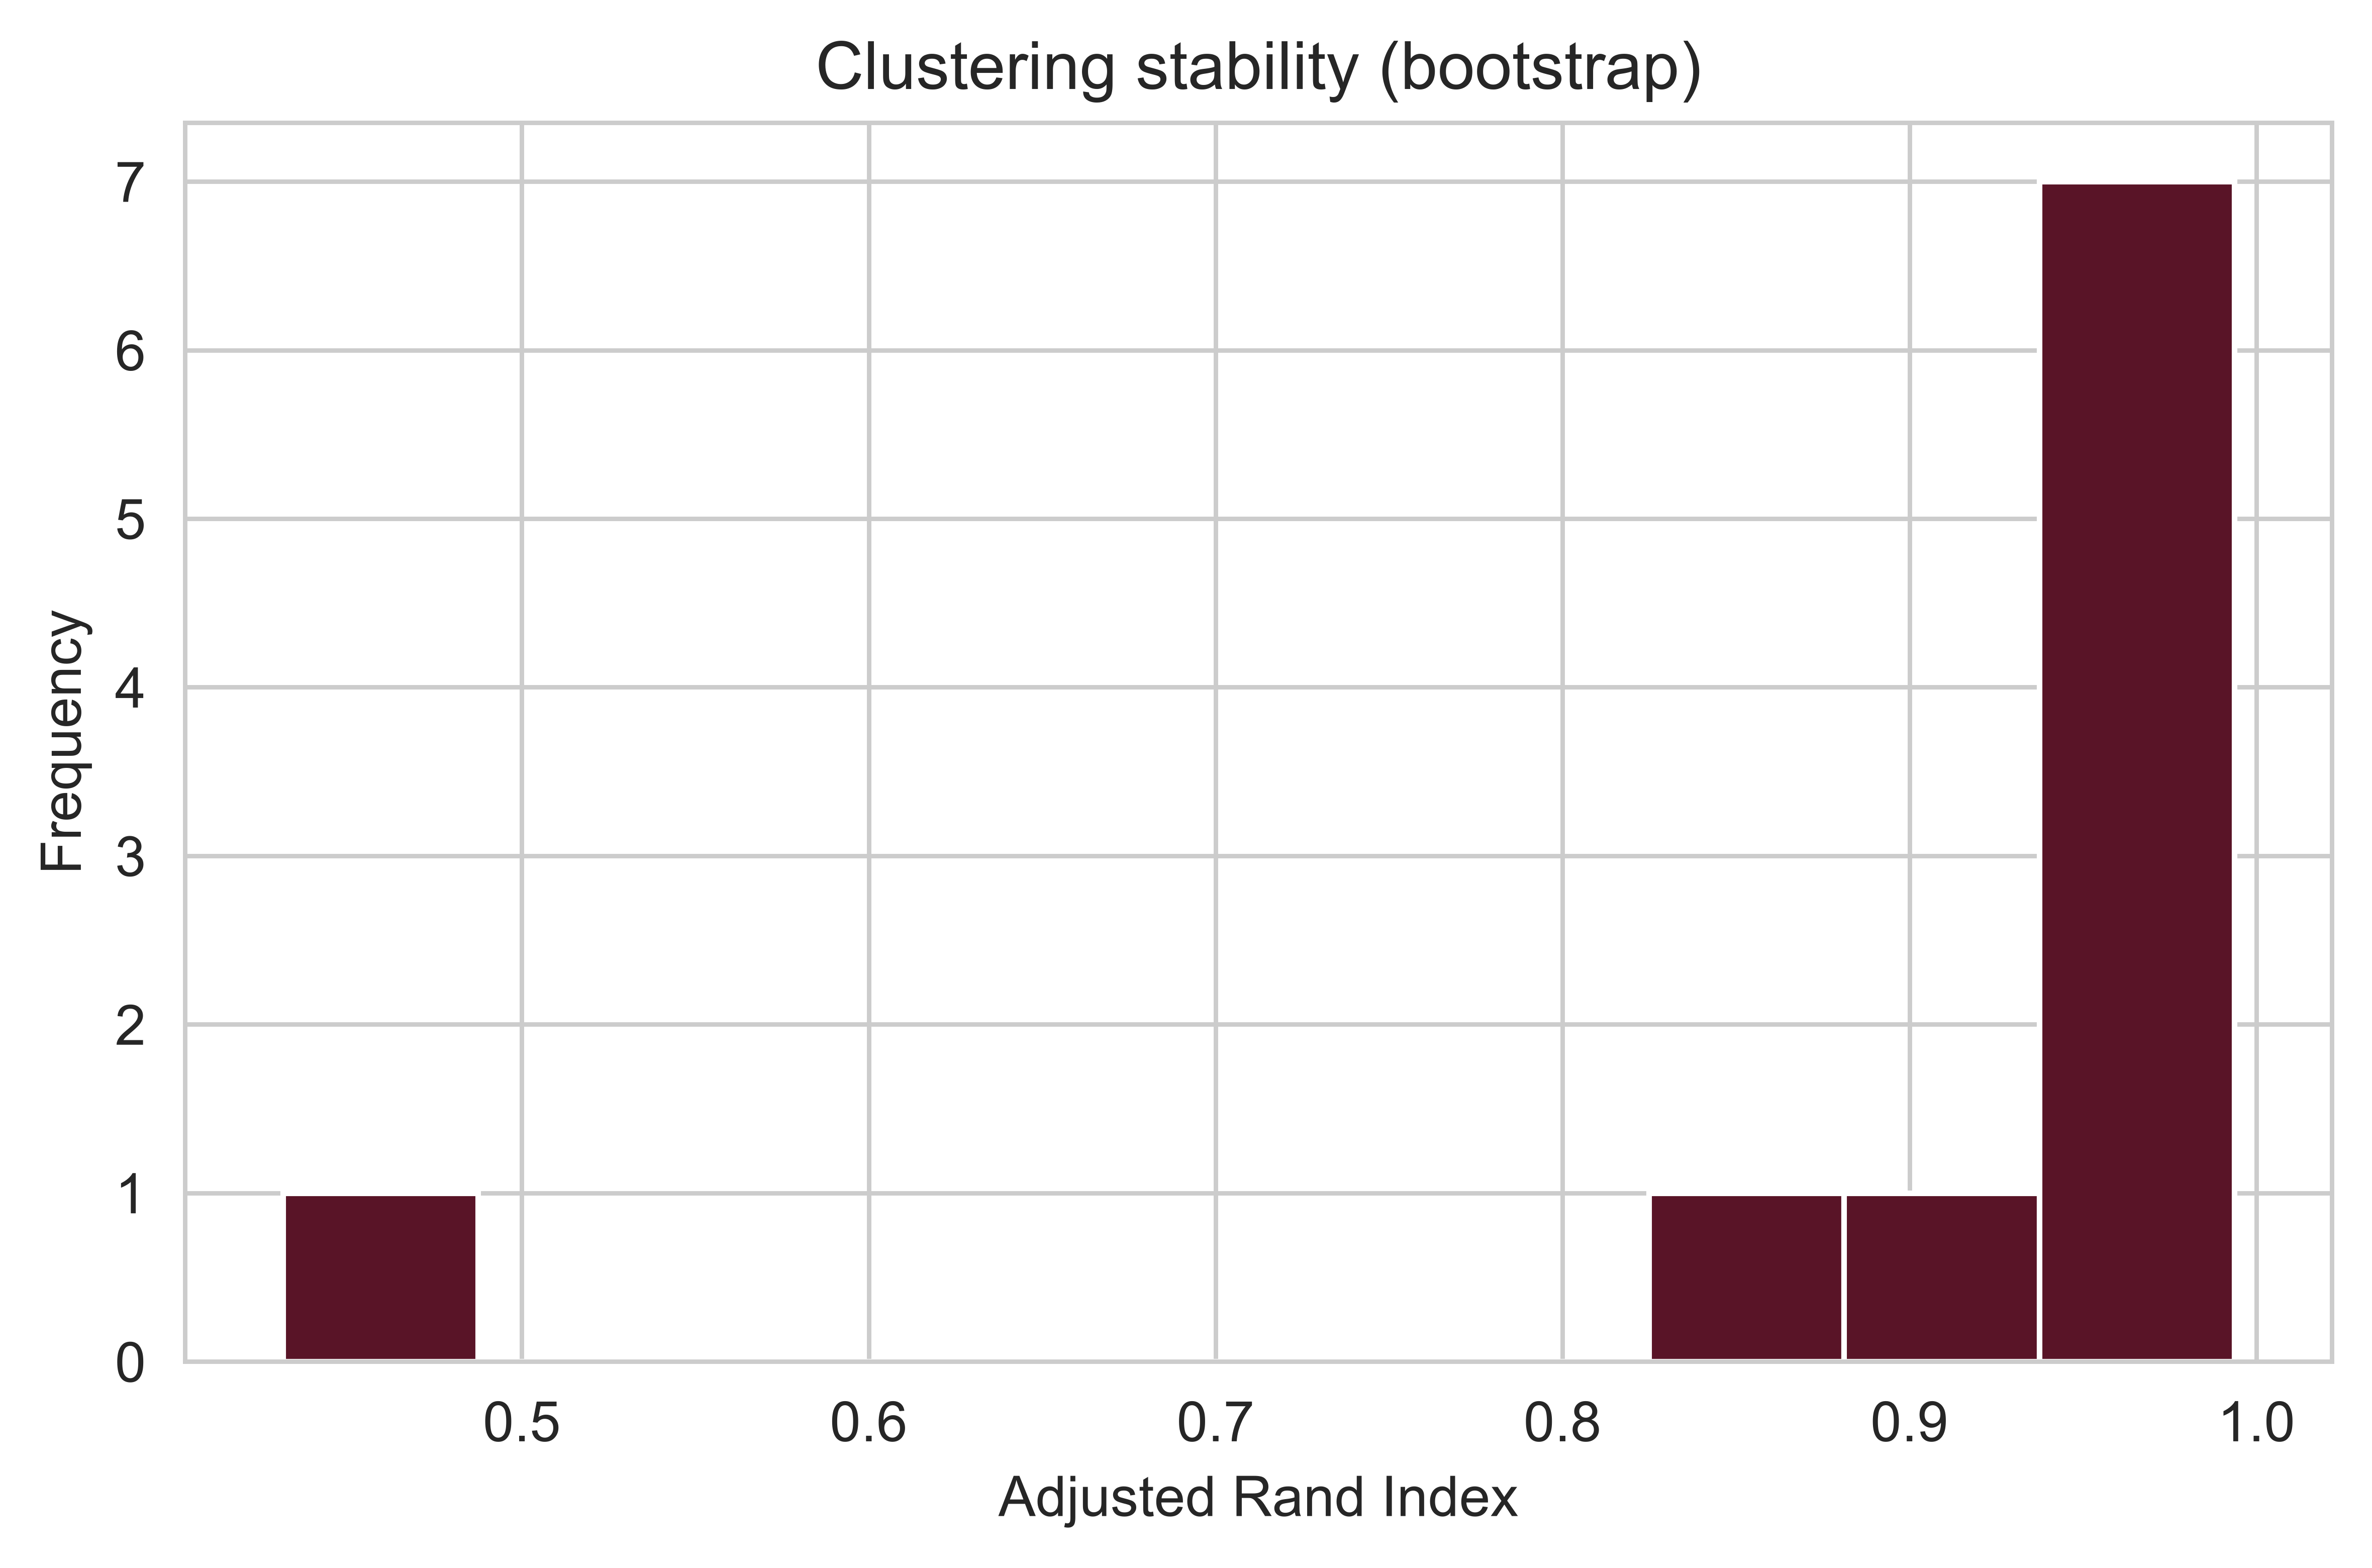

In [42]:
n_boot = 10
ari_scores = []
X_best = results["baseline"]["X"]
k_best = results["baseline"]["k"]
labels_orig = mob3["cluster"].values

rng = np.random.default_rng(42)
for i in range(n_boot):
    idx = rng.choice(len(X_best), size=len(X_best), replace=True)
    km_boot = KMeans(n_clusters=k_best, random_state=i, n_init=10)
    labels_boot = km_boot.fit_predict(X_best[idx])
    ari_scores.append(adjusted_rand_score(labels_orig[idx], labels_boot))

print(f"Mean ARI over {n_boot} bootstrap resamples: {np.mean(ari_scores):.3f} (± {np.std(ari_scores):.3f})")

plt.figure(figsize=(6, 4))
plt.hist(ari_scores, bins=10, color="#591427", edgecolor="white")
plt.xlabel("Adjusted Rand Index")
plt.ylabel("Frequency")
plt.title("Clustering stability (bootstrap)")
plt.tight_layout()
plt.savefig("./Plots/clustering_stability_bootstrap.png", dpi=800)
plt.show()